In [2]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
TICKERS = ["RYAAY", "LHA.DE", "AF.PA", "IAG.L"]
OUTPUT_DIR = "output"

# "annual" gives ~5 fiscal years; "quarterly" gives ~4-7 quarters but is patchier.
FREQ = "annual"

# Flow items (revenue, COGS) are per-period, so the day count has to match the
# period or DSO/DPO/DIO come out ~4x too high on quarterly data.
DAYS_IN_PERIOD = {"annual": 365, "quarterly": 91}

In [4]:
BALANCE_ITEMS = {
    "receivables": ["Accounts Receivable", "Receivables", "Net Receivables"],
    "payables": ["Accounts Payable", "Payables", "Payables And Accrued Expenses"],
    "inventory": ["Inventory", "Inventories"],
    "current_assets": ["Current Assets", "Total Current Assets"],
    "current_liabilities": ["Current Liabilities", "Total Current Liabilities"],
    "cash": ["Cash And Cash Equivalents", "Cash Cash Equivalents And Short Term Investments"],
}
INCOME_ITEMS = {
    "revenue": ["Total Revenue", "Revenue"],
    "cogs": ["Cost Of Revenue", "Reconciled Cost Of Revenue", "Cost Of Goods Sold"],
}


def _val(df, candidates, period):
    """Value of the first matching row label at `period` - None if absent or NaN.

    Filers label these rows inconsistently, hence the candidate lists. yfinance
    also leaves NaN in cells it could not fill, and NaN is truthy, so this tests
    for it explicitly rather than relying on `if x`.
    """
    for name in candidates:
        if name in df.index:
            v = df.loc[name, period]
            return None if pd.isna(v) else float(v)
    return None

In [5]:
def fetch_statements(ticker, freq="annual"):
    """Balance sheet + income statement for one ticker, every period Yahoo returns."""
    t = yf.Ticker(ticker)
    if freq == "annual":
        bs, inc = t.balance_sheet, t.financials
    elif freq == "quarterly":
        bs, inc = t.quarterly_balance_sheet, t.quarterly_financials
    else:
        raise ValueError(f"freq must be 'annual' or 'quarterly', got {freq!r}")

    if bs.empty or inc.empty:
        raise ValueError(f"No data returned for {ticker} (check ticker or network access)")

    return bs, inc


def _ratio(numerator, denominator, scale=1.0, ndigits=2):
    """Guarded division - None unless both sides exist and the denominator is non-zero."""
    if numerator is None or denominator is None or denominator == 0:
        return None
    return round(numerator / denominator * scale, ndigits)


# ratios are the analysis; the raw currency amounts are kept alongside them so the
# stress test downstream can work off absolute cash and cost, not just multiples
RATIO_COLS = ["DSO", "DPO", "DIO", "CCC", "Current Ratio", "Quick Ratio", "Cash Ratio"]
INPUT_COLS = ["revenue", "cogs", "cash", "receivables", "payables",
              "inventory", "current_assets", "current_liabilities"]


def calculate_ratios(bs, inc, ticker, days=365):
    """DSO, DPO, DIO, CCC and the liquidity ratios for every period the two
    statements share. Uses period-end balances rather than two-period averages,
    to keep this a first-pass model."""
    rows = []

    # a period is only usable if it appears on both statements
    for period in sorted(set(bs.columns) & set(inc.columns), reverse=True):
        receivables = _val(bs, BALANCE_ITEMS["receivables"], period)
        payables = _val(bs, BALANCE_ITEMS["payables"], period)
        inventory = _val(bs, BALANCE_ITEMS["inventory"], period)
        current_assets = _val(bs, BALANCE_ITEMS["current_assets"], period)
        current_liabilities = _val(bs, BALANCE_ITEMS["current_liabilities"], period)
        cash = _val(bs, BALANCE_ITEMS["cash"], period)
        revenue = _val(inc, INCOME_ITEMS["revenue"], period)
        cogs = _val(inc, INCOME_ITEMS["cogs"], period)

        # Yahoo pads the oldest column with an almost-empty stub (~1 of 78 fields
        # populated). Skip it - otherwise the "missing inventory means zero" rule
        # below reports a confident DIO of 0 for a period holding no data at all.
        if all(v is None for v in (receivables, payables, current_assets,
                                   current_liabilities, cash, revenue, cogs)):
            continue

        r = {"ticker": ticker, "period": period}
        r["DSO"] = _ratio(receivables, revenue, days, 1)
        r["DPO"] = _ratio(payables, cogs, days, 1)
        # Airlines carry little or no inventory - a missing line item means zero
        # days here, not "unknown", so DIO and CCC stay computable.
        r["DIO"] = 0.0 if inventory is None else _ratio(inventory, cogs, days, 1)

        if None not in (r["DSO"], r["DIO"], r["DPO"]):
            r["CCC"] = round(r["DSO"] + r["DIO"] - r["DPO"], 1)
        else:
            r["CCC"] = None

        r["Current Ratio"] = _ratio(current_assets, current_liabilities)
        quick_assets = None if current_assets is None else current_assets - (inventory or 0)
        r["Quick Ratio"] = _ratio(quick_assets, current_liabilities)
        r["Cash Ratio"] = _ratio(cash, current_liabilities)

        r.update({
            "revenue": revenue, "cogs": cogs, "cash": cash,
            "receivables": receivables, "payables": payables,
            "inventory": inventory, "current_assets": current_assets,
            "current_liabilities": current_liabilities,
        })

        rows.append(r)

    return rows

In [6]:
def build_history(tickers, freq=FREQ):
    """Fetch + compute every available period for every ticker. A failure on one
    name is reported and skipped rather than killing the whole run."""
    days = DAYS_IN_PERIOD[freq]
    rows = []
    for ticker in tickers:
        try:
            bs, inc = fetch_statements(ticker, freq=freq)
            rows.extend(calculate_ratios(bs, inc, ticker, days=days))
        except Exception as exc:
            print(f"[skip] {ticker}: {exc}")

    if not rows:
        raise RuntimeError("No tickers returned usable data")

    df = pd.DataFrame(rows)
    df["period"] = pd.to_datetime(df["period"])
    return df.sort_values(["ticker", "period"]).set_index(["ticker", "period"])


frame = build_history(TICKERS)

# split the two halves: `history` is what the charts read, `inputs` feeds the
# stress test. Same rows, same index - only the columns differ.
history = frame[RATIO_COLS]
inputs = frame[INPUT_COLS]

os.makedirs(OUTPUT_DIR, exist_ok=True)
history.to_csv(os.path.join(OUTPUT_DIR, "working_capital_ratios.csv"))

# latest period per ticker - the single-year view from before
latest = history.groupby(level="ticker").tail(1).droplevel("period")
latest_inputs = inputs.groupby(level="ticker").tail(1).droplevel("period")

print(f"{len(history)} periods across {history.index.get_level_values('ticker').nunique()} tickers\n")
history

16 periods across 4 tickers



DSO   DPO   DIO   CCC  Current Ratio  Quick Ratio  \
ticker period                                                           
AF.PA  2022-12-31  24.7  42.1  12.6  -4.8           0.82         0.76   
       2023-12-31  26.2  38.8  13.5   0.9           0.74         0.69   
       2024-12-31  23.8  39.2  14.4  -1.0           0.65         0.59   
       2025-12-31  24.5  39.6  14.4  -0.7           0.62         0.56   
IAG.L  2022-12-31  21.0  57.1   6.8 -29.3           0.79         0.77   
       2023-12-31  19.3  51.0   7.9 -23.8           0.62         0.59   
       2024-12-31  20.2  49.9   9.2 -20.5           0.78         0.75   
       2025-12-31  14.8  42.7  10.3 -17.6           0.70         0.66   
LHA.DE 2022-12-31  35.3  55.0  10.9  -8.8           0.86         0.82   
       2023-12-31  23.8  49.9  16.7  -9.4           0.81         0.74   
       2024-12-31  23.7  49.8  17.9  -8.2           0.83         0.75   
       2025-12-31  22.2  46.1  17.3  -6.6           0.81         0.73   
RYAAY  2023-03-31   2.0  45.5   0.3 -43.2           0.80         0.80   
       2024-03-31   2.1  27.6   0.2 -25.3           0.91         0.91   
       2025-03-31   1.9  22.7   0.1 -20.7           0.74         0.74   
       2026-03-31   1.0  18.5   0.1 -17.4           0.90         0.90   

                   Cash Ratio  
ticker period                  
AF.PA  2022-12-31        0.48  
       2023-12-31        0.38  
       2024-12-31        0.30  
       2025-12-31        0.28  
IAG.L  2022-12-31        0.55  
       2023-12-31        0.31  
       2024-12-31        0.42  
       2025-12-31        0.40  
LHA.DE 2022-12-31        0.10  
       2023-12-31        0.08  
       2024-12-31        0.09  
       2025-12-31        0.06  
RYAAY  2023-03-31        0.48  
       2024-03-31        0.61  
       2025-03-31        0.47  
       2026-03-31        0.32

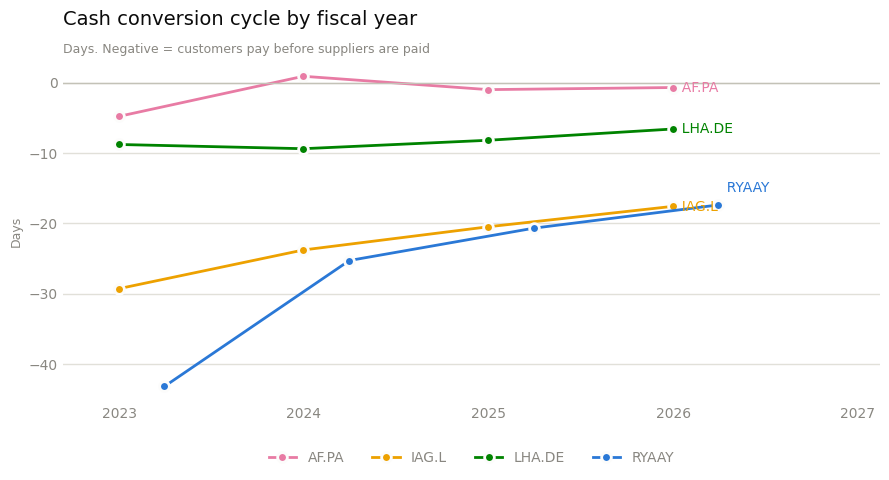

In [7]:
import matplotlib.dates as mdates

# categorical slots 1-4, assigned in fixed order and pinned per ticker so a
# change to TICKERS never repaints the survivors
SERIES_COLORS = {
    "RYAAY": "#2a78d6",   # blue
    "LHA.DE": "#008300",  # green
    "AF.PA": "#e87ba4",   # magenta
    "IAG.L": "#eda100",   # yellow
}
MUTED, BASELINE, INK, GRID, SURFACE = "#898781", "#c3c2b7", "#0b0b0b", "#e1e0d9", "#fcfcfb"


def plot_series(ax, metric):
    """One line per ticker for `metric`. Returns [ticker, x, y, colour] endpoints."""
    endpoints = []
    for ticker, grp in history.groupby(level="ticker"):
        s = grp[metric].droplevel("ticker").dropna()
        if s.empty:
            continue
        color = SERIES_COLORS.get(ticker, MUTED)
        ax.plot(s.index, s.values, color=color, linewidth=2, marker="o",
                markersize=7, markeredgecolor=SURFACE, markeredgewidth=2, label=ticker)
        endpoints.append([ticker, s.index[-1], s.values[-1], color])
    return endpoints


def direct_label_ends(ax, endpoints, gap_frac=0.055):
    """Label each line at its last point, so identity is never carried by colour
    alone. Carriers can finish within a hair of each other, so nudge the labels
    apart vertically where they would otherwise overprint."""
    lo, hi = ax.get_ylim()
    min_gap = gap_frac * (hi - lo)
    endpoints = sorted(endpoints, key=lambda e: e[2])
    for i in range(1, len(endpoints)):
        if endpoints[i][2] - endpoints[i - 1][2] < min_gap:
            endpoints[i][2] = endpoints[i - 1][2] + min_gap

    for ticker, x, label_y, color in endpoints:
        ax.annotate(f"  {ticker}", (x, label_y), color=color, fontsize=10,
                    va="center", ha="left", annotation_clip=False)


def style_axes(ax, ylabel=None, date_axis=True):
    """Recessive grid and axes. `date_axis=False` for the stress test, whose x is
    a shock percentage rather than a fiscal year."""
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    if date_axis:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(colors=MUTED, labelsize=10, length=0)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)


def add_right_headroom(ax, frac=0.20):
    """Room on the right so the direct labels sit inside the figure."""
    x_lo, x_hi = ax.get_xlim()
    ax.set_xlim(x_lo - 0.04 * (x_hi - x_lo), x_hi + frac * (x_hi - x_lo))


def muted_legend(ax, **kwargs):
    legend = ax.legend(frameon=False, fontsize=10, **kwargs)
    for text in legend.get_texts():
        text.set_color(MUTED)
    return legend


fig, ax = plt.subplots(figsize=(9, 5))

direct_label_ends(ax, plot_series(ax, "CCC"))

ax.axhline(0, color=BASELINE, linewidth=1)
ax.set_title("Cash conversion cycle by fiscal year", fontsize=14, loc="left", color=INK, pad=26)
ax.text(0, 1.015, "Days. Negative = customers pay before suppliers are paid",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")
style_axes(ax, ylabel="Days")
add_right_headroom(ax)
muted_legend(ax, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.22))

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "ccc_history.png"), dpi=200, bbox_inches="tight")
plt.show()

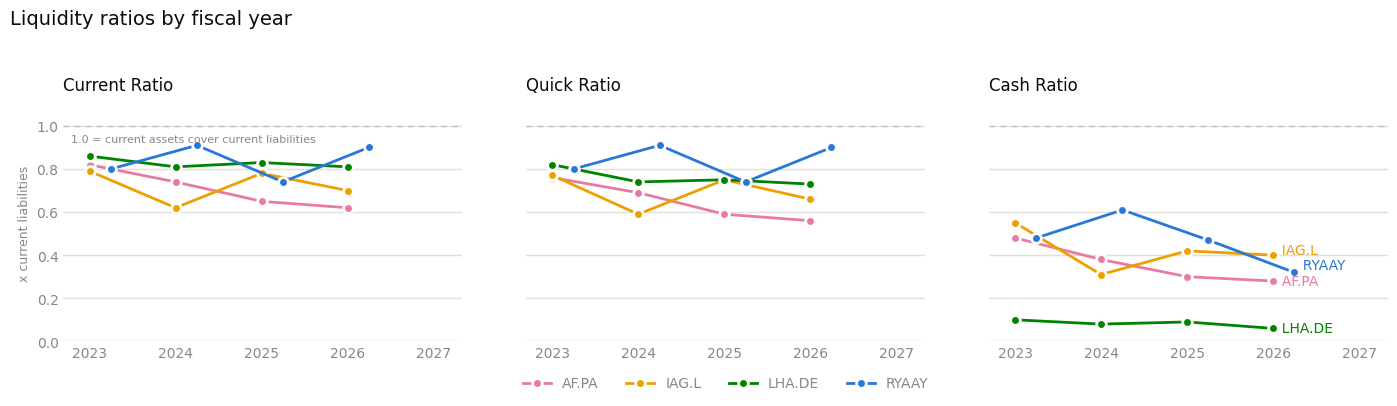

In [8]:
LIQUIDITY = ["Current Ratio", "Quick Ratio", "Cash Ratio"]

# One panel per ratio rather than 12 lines on one plot. All three are multiples
# of the same denominator (current liabilities), so both axes are shared - the
# panels stay directly comparable and the drop from Current to Cash is the point.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True, sharex=True)

for i, (ax, metric) in enumerate(zip(axes, LIQUIDITY)):
    endpoints = plot_series(ax, metric)

    # 1.0 = current assets exactly cover current liabilities
    ax.axhline(1.0, color=BASELINE, linewidth=1, linestyle=(0, (4, 4)))
    ax.set_title(metric, fontsize=12, loc="left", color=INK, pad=10)
    style_axes(ax, ylabel="x current liabilities" if i == 0 else None)

    # label only the last panel - repeating four labels per panel is noise,
    # and the shared legend already carries identity
    if i == len(LIQUIDITY) - 1:
        direct_label_ends(ax, endpoints, gap_frac=0.07)

axes[0].set_ylim(0, 1.1)
# shared x, so this widens every panel at once and keeps the three comparable
add_right_headroom(axes[0], frac=0.26)
axes[0].annotate(
    "1.0 = current assets cover current liabilities",
    xy=(0.02, 1.0), xycoords=("axes fraction", "data"),
    xytext=(0, -6), textcoords="offset points",
    fontsize=8, color=MUTED, va="top",
)

fig.suptitle("Liquidity ratios by fiscal year", fontsize=14, x=0.005, ha="left", color=INK)
muted_legend(axes[1], ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.26))

fig.tight_layout(rect=(0, 0.04, 1, 0.94))
fig.savefig(os.path.join(OUTPUT_DIR, "liquidity_history.png"), dpi=200, bbox_inches="tight")
plt.show()

In [9]:
import numpy as np

# --- Liquidity stress test -------------------------------------------------
# How long does cash on hand last if traffic collapses and stays collapsed?
#
# Model: revenue falls by `shock` and stays there. Variable cost (fuel, handling,
# airport and distribution fees) falls with it; fixed cost (fleet ownership,
# crew, maintenance base, admin) does not. The gap is the monthly cash burn.
#
# 55/45 variable/fixed is the conventional short-haul split. It is an assumption,
# not a disclosure - it is the single biggest lever in this model, so SENSITIVITY
# below re-runs the whole thing at 45% and 65% to show how much it actually moves.
VARIABLE_COST_SHARE = 0.55
SENSITIVITY = [0.45, 0.55, 0.65]

SCENARIOS = {
    "Mild -20%": 0.20,
    "Severe -40%": 0.40,
    "COVID-like -70%": 0.70,
}


def monthly_burn(revenue, cogs, shock, variable_share=VARIABLE_COST_SHARE):
    """Cash consumed per month at a sustained `shock` fall in revenue.

    Negative means the carrier is still generating cash at that shock level.
    """
    monthly_revenue = revenue / 12
    monthly_cost = cogs / 12
    fixed = monthly_cost * (1 - variable_share)
    variable = monthly_cost * variable_share * (1 - shock)
    return (fixed + variable) - monthly_revenue * (1 - shock)


def months_of_liquidity(revenue, cogs, cash, shock, variable_share=VARIABLE_COST_SHARE):
    """Months `cash` covers the burn. inf if the shock is not deep enough to burn.

    Only cash counts as the buffer. Receivables are deliberately excluded: in a
    demand shock they shrink alongside revenue instead of cushioning it, and
    undrawn credit lines are not in these statements at all. So this is a floor,
    not a forecast - real carriers also raise debt, defer capex and ground fleet.
    """
    burn = monthly_burn(revenue, cogs, shock, variable_share)
    if burn <= 0:
        return np.inf
    return cash / burn


def breakeven_shock(revenue, cogs, variable_share=VARIABLE_COST_SHARE):
    """Revenue decline at which monthly cash flow turns negative.

    Setting burn to zero and solving: fixed + variable*(1-s) = revenue*(1-s),
    so s = 1 - fixed / (revenue - variable). Undefined when contribution margin
    is non-positive, i.e. the carrier already burns cash before any shock.
    """
    monthly_revenue = revenue / 12
    variable = (cogs / 12) * variable_share
    fixed = (cogs / 12) * (1 - variable_share)
    contribution = monthly_revenue - variable
    if contribution <= 0:
        return np.nan
    return 1 - fixed / contribution


def run_stress(inputs_row_frame, variable_share=VARIABLE_COST_SHARE):
    """Scenario table for every ticker at one fixed/variable assumption."""
    out = []
    for ticker, row in inputs_row_frame.iterrows():
        revenue, cogs, cash = row["revenue"], row["cogs"], row["cash"]
        if any(pd.isna(v) for v in (revenue, cogs, cash)):
            print(f"[skip] {ticker}: missing revenue/cogs/cash")
            continue
        rec = {"ticker": ticker, "Cash (bn)": round(cash / 1e9, 2)}
        for name, shock in SCENARIOS.items():
            rec[name] = months_of_liquidity(revenue, cogs, cash, shock, variable_share)
        rec["Breakeven shock"] = breakeven_shock(revenue, cogs, variable_share)
        out.append(rec)
    return pd.DataFrame(out).set_index("ticker")


stress = run_stress(latest_inputs)
stress.to_csv(os.path.join(OUTPUT_DIR, "stress_test.csv"))


# Just past its breakeven a carrier burns a rounding error per month, so the
# months figure explodes - Ryanair prints 545 months at -40%. That is arithmetic,
# not resilience: nobody plans 45 years out on a static shock model. Cap the
# display, and keep the raw numbers in the CSV for anyone who wants them.
DISPLAY_CAP = 36


def _months(v):
    if np.isinf(v):
        return "no burn"
    if v > DISPLAY_CAP:
        return f">{DISPLAY_CAP}"
    return f"{v:.1f}"


def _fmt(df):
    """inf is a real result here (still cash-generative), not a missing value -
    spell it out rather than printing 'inf' at the reader."""
    d = df.copy()
    for col in SCENARIOS:
        d[col] = d[col].map(_months)
    d["Breakeven shock"] = d["Breakeven shock"].map(
        lambda v: "n/a" if pd.isna(v) else f"-{v:.0%}")
    return d


print(f"Months of liquidity at {VARIABLE_COST_SHARE:.0%} variable cost")
print("(cash only; latest fiscal year; reporting currency, all four report in EUR)\n")
print(_fmt(stress).to_string())

print("\n\nSensitivity of the severe case to the cost-split assumption")
print("Months of liquidity at -40% revenue:\n")
sens = pd.DataFrame({
    f"{v:.0%} variable": run_stress(latest_inputs, v)["Severe -40%"]
    for v in SENSITIVITY
})
print(sens.map(_months).to_string())
print(f"\n('>{DISPLAY_CAP}' and 'no burn' both mean the shock is not deep enough "
      "to threaten this carrier)")

Months of liquidity at 55% variable cost
(cash only; latest fiscal year; reporting currency, all four report in EUR)

        Cash (bn) Mild -20% Severe -40% COVID-like -70% Breakeven shock
ticker                                                                 
AF.PA        4.71   no burn     no burn            10.2            -41%
IAG.L        7.42   no burn     no burn            16.7            -43%
LHA.DE       1.16   no burn         4.3             1.5            -24%
RYAAY        2.73   no burn         >36            12.0            -39%


Sensitivity of the severe case to the cost-split assumption
Months of liquidity at -40% revenue:

       45% variable 55% variable 65% variable
ticker                                       
AF.PA           >36      no burn      no burn
IAG.L           >36      no burn      no burn
LHA.DE          3.0          4.3          7.4
RYAAY           >36          >36      no burn

('>36' and 'no burn' both mean the shock is not deep enough to threaten t

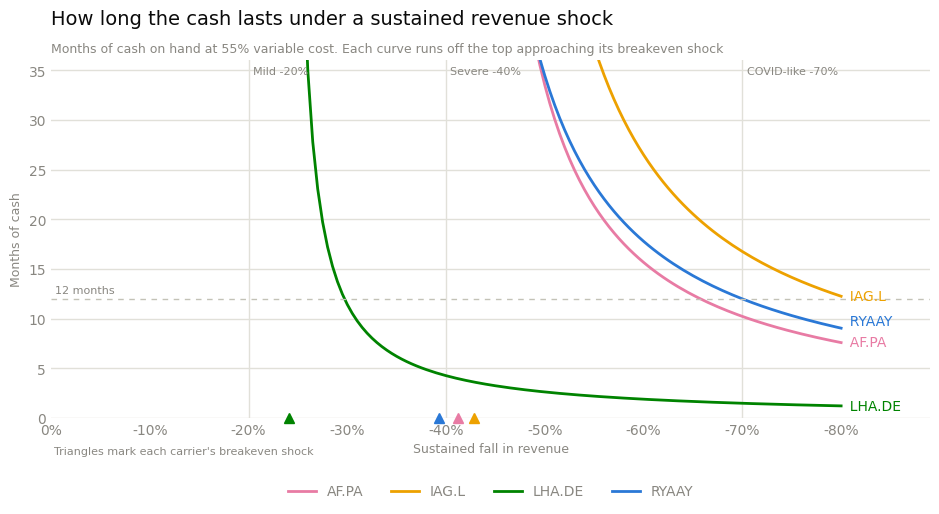

In [10]:
# A three-scenario bar chart would hide the shape of the thing. Sweeping the
# shock continuously shows where each carrier's curve falls off a cliff, and the
# x-intercept of each line is its breakeven shock - the same number as the table,
# read off the chart.
SHOCK_GRID = np.linspace(0, 0.80, 161)
Y_CAP = 36  # months; lines run off the top rather than being squashed flat

fig, ax = plt.subplots(figsize=(9.5, 5.4))

endpoints = []
for ticker, row in latest_inputs.iterrows():
    revenue, cogs, cash = row["revenue"], row["cogs"], row["cash"]
    if any(pd.isna(v) for v in (revenue, cogs, cash)):
        continue
    months = np.array([
        months_of_liquidity(revenue, cogs, cash, s) for s in SHOCK_GRID
    ])
    # inf = not burning yet, so there is no curve to draw there
    months[np.isinf(months)] = np.nan

    color = SERIES_COLORS.get(ticker, MUTED)
    ax.plot(SHOCK_GRID, months, color=color, linewidth=2, label=ticker)
    endpoints.append([ticker, SHOCK_GRID[-1], months[-1], color])

# 12 months is the conventional going-concern horizon auditors look at
ax.axhline(12, color=BASELINE, linewidth=1, linestyle=(0, (4, 4)))
ax.annotate("12 months", xy=(0.005, 12), xycoords=("axes fraction", "data"),
            xytext=(0, 4), textcoords="offset points", fontsize=8, color=MUTED)

for name, shock in SCENARIOS.items():
    ax.axvline(shock, color=GRID, linewidth=1, zorder=0)
    ax.annotate(name, xy=(shock, 1.0), xycoords=("data", "axes fraction"),
                xytext=(3, -10), textcoords="offset points",
                fontsize=8, color=MUTED, ha="left")

ax.set_ylim(0, Y_CAP)
ax.set_xlim(0, 0.80 + 0.09)
# no "-0%" at the origin
ax.xaxis.set_major_formatter(lambda v, _: "0%" if v == 0 else f"-{v:.0%}")
style_axes(ax, ylabel="Months of cash", date_axis=False)
direct_label_ends(ax, endpoints, gap_frac=0.06)

ax.set_title("How long the cash lasts under a sustained revenue shock",
             fontsize=14, loc="left", color=INK, pad=26)
# The curve is asymptotic at breakeven, so it enters the frame well to the right
# of it - IAG.L breaks even at -43% but only drops under 36 months near -55%.
# Say so, rather than letting the reader misread the entry point as breakeven.
ax.text(0, 1.015,
        f"Months of cash on hand at {VARIABLE_COST_SHARE:.0%} variable cost. "
        f"Each curve runs off the top approaching its breakeven shock",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")

# mark the actual breakevens on the axis, so the table's numbers are locatable here
for ticker, row in latest_inputs.iterrows():
    s = breakeven_shock(row["revenue"], row["cogs"])
    if pd.isna(s):
        continue
    ax.annotate("", xy=(s, 0), xytext=(s, -0.9), textcoords=("data", "data"),
                annotation_clip=False)
    ax.plot([s], [0], marker="^", markersize=7, clip_on=False,
            color=SERIES_COLORS.get(ticker, MUTED))
ax.annotate("Triangles mark each carrier's breakeven shock",
            xy=(0.0, 0), xytext=(2, -26), textcoords="offset points",
            xycoords=("axes fraction", "data"), fontsize=8, color=MUTED)
ax.set_xlabel("Sustained fall in revenue", color=MUTED, fontsize=9)
muted_legend(ax, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.26))

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "stress_test.png"), dpi=200, bbox_inches="tight")
plt.show()

In [11]:

# This cell is not self-contained: it reads `latest` / `latest_inputs` from the
# fetch cell and `stress`, `run_stress`, `_months`, DISPLAY_CAP and SENSITIVITY
# from the stress-test cell. Run out of order against a fresh kernel it dies on a
# bare NameError partway through, so check the whole list up front and name the fix.
_REQUIRED = ["latest", "latest_inputs", "stress", "run_stress", "_months",
             "DISPLAY_CAP", "SENSITIVITY", "OUTPUT_DIR"]
_missing = [n for n in _REQUIRED if n not in globals()]
if _missing:
    raise NameError(
        f"this cell needs {', '.join(_missing)} from the cells above. "
        "Run the notebook in order first (Kernel > Restart Kernel and Run All Cells)."
    )

# --- Composite risk ranking ------------------------------------------------
# The three views above disagree about who is fragile. CCC says one thing, the
# liquidity ratios another, the stress test a third. This collapses them into a
# single ordering so the disagreement is visible rather than left to the reader.
#
# Scores are min-max scaled *within this peer set*: 100 is the best of these four
# carriers on that metric, 0 the worst. They are relative, not absolute - a 100
# is not a statement that the number is safe, only that it is the least bad here.
# Weights are a judgement call and are stated openly so they can be argued with.
RISK_METRICS = {
    # metric:            (source, direction, weight)
    "Cash Ratio":        ("ratios", "higher", 0.15),
    "Current Ratio":     ("ratios", "higher", 0.10),
    "CCC":               ("ratios", "lower",  0.20),
    "Breakeven shock":   ("stress", "higher", 0.30),
    "Severe -40%":       ("stress", "higher", 0.25),
}
# survival under a shock is what actually kills an airline, so the two stress
# columns carry 55% between them; the balance-sheet snapshot carries the rest
assert abs(sum(w for _, _, w in RISK_METRICS.values()) - 1) < 1e-9


def _scale(series, direction):
    """Min-max to 0-100, higher = lower risk. NaN scores 0 - a metric we could
    not compute is treated as the worst case rather than quietly dropped, which
    would otherwise reward a carrier for missing data."""
    s = pd.to_numeric(series, errors="coerce")
    if direction == "lower":
        s = -s
    lo, hi = s.min(), s.max()
    if pd.isna(lo) or hi == lo:
        # every carrier identical (or all missing) - the metric separates nobody
        return s.notna().astype(float) * 50.0
    return ((s - lo) / (hi - lo) * 100).fillna(0.0)


def composite_risk(ratios_frame, stress_frame, cap=DISPLAY_CAP):
    """Weighted composite of the working-capital and stress-test metrics.

    `Severe -40%` is capped before scaling: uncapped, Ryanair's ~545 months would
    compress the other three into the bottom of the range and the metric would
    only be recording "is Ryanair", not ranking anyone. inf is capped the same way.
    The cap applies to the score only - the reported column keeps the real number.
    """
    source = {"ratios": ratios_frame, "stress": stress_frame}
    raw, scores = {}, {}

    for metric, (src, direction, _) in RISK_METRICS.items():
        col = source[src][metric]
        raw[metric] = col
        scores[metric] = _scale(col.clip(upper=cap) if metric == "Severe -40%" else col,
                                direction)

    scores = pd.DataFrame(scores)
    weights = pd.Series({m: w for m, (_, _, w) in RISK_METRICS.items()})
    composite = (scores * weights).sum(axis=1)

    out = pd.DataFrame(raw)
    out["Score"] = composite.round(1)
    out["Rank"] = composite.rank(ascending=False, method="min").astype(int)
    return out.sort_values("Rank"), scores.round(1)


# the two frames are indexed on ticker but need not share an order or a length -
# a carrier missing from either side would silently vanish from the composite,
# so line them up explicitly and say so if anyone drops out
common = latest.index.intersection(stress.index)
dropped = latest.index.difference(stress.index).union(stress.index.difference(latest.index))
if len(dropped):
    print(f"[skip] not ranked (missing from one of the two tables): {', '.join(dropped)}\n")

risk, components = composite_risk(latest.loc[common], stress.loc[common])
risk.to_csv(os.path.join(OUTPUT_DIR, "composite_risk.csv"))


def _fmt_risk(df):
    d = df.copy()
    d["Breakeven shock"] = d["Breakeven shock"].map(
        lambda v: "n/a" if pd.isna(v) else f"-{v:.0%}")
    d["Severe -40%"] = d["Severe -40%"].map(_months)
    d["CCC"] = d["CCC"].map(lambda v: "n/a" if pd.isna(v) else f"{v:+.1f}d")
    for col in ("Cash Ratio", "Current Ratio"):
        d[col] = d[col].map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}")
    return d[["Rank", "Score"] + list(RISK_METRICS)]


weight_note = ", ".join(f"{m} {w:.0%}" for m, (_, _, w) in RISK_METRICS.items())
print("Composite risk ranking - rank 1 = most resilient of these four")
print(f"(weights: {weight_note})\n")
print(_fmt_risk(risk).to_string())

print("\n\nComponent scores (0 = worst of the four on that metric, 100 = best)\n")
print(components.loc[risk.index].to_string())

# The composite inherits the stress test's biggest assumption, so re-rank at both
# ends of the sensitivity range. If the order holds across all three, the ranking
# is a property of the carriers; if it flips, it is a property of the assumption.
orders = {}
for share in SENSITIVITY:
    alt = run_stress(latest_inputs.loc[common], share)
    alt_risk, _ = composite_risk(latest.loc[common], alt)
    orders[f"{share:.0%} variable"] = list(alt_risk.index)

print("\n\nDoes the ranking survive the cost-split assumption?\n")
for label, order in orders.items():
    print(f"  {label}: {' > '.join(order)}")
stable = len({tuple(o) for o in orders.values()}) == 1
print("\n" + ("Order is unchanged across the range - the ranking is not an "
              "artefact of the 55% split."
              if stable else
              "Order changes across the range - the ranking is only as firm as "
              "the cost-split assumption. Read it alongside the rows above, not "
              "instead of them."))

Composite risk ranking - rank 1 = most resilient of these four
(weights: Cash Ratio 15%, Current Ratio 10%, CCC 20%, Breakeven shock 30%, Severe -40% 25%)

        Rank  Score Cash Ratio Current Ratio     CCC Breakeven shock Severe -40%
ticker                                                                          
IAG.L      1   92.9       0.40          0.70  -17.6d            -43%     no burn
RYAAY      2   90.7       0.32          0.90  -17.4d            -39%         >36
AF.PA      3   62.2       0.28          0.62   -0.7d            -41%     no burn
LHA.DE     4   13.8       0.06          0.81   -6.6d            -24%         4.3


Component scores (0 = worst of the four on that metric, 100 = best)

        Cash Ratio  Current Ratio    CCC  Breakeven shock  Severe -40%
ticker                                                                
IAG.L        100.0           28.6  100.0            100.0        100.0
RYAAY         76.5          100.0   98.8             81.5        100.0
AF.

In [12]:
# This cell reads `risk`, `RISK_METRICS` and `_scale` from the composite cell
# above, and DISPLAY_CAP from the stress-test cell. Same guard as that cell -
# fail with the fix named rather than on a bare NameError halfway down.
_REQUIRED = ["risk", "RISK_METRICS", "_scale", "DISPLAY_CAP"]
_missing = [n for n in _REQUIRED if n not in globals()]
if _missing:
    raise NameError(
        f"this cell needs {', '.join(_missing)} from the cells above. "
        "Run the notebook in order first (Kernel > Restart Kernel and Run All Cells)."
    )

# --- Weight sensitivity ----------------------------------------------------
# The cell above tested the ranking against the stress test's cost-split
# assumption. The other soft assumption is the weights themselves, which are a
# judgement call. Re-rank at a flat 20% each: if the order holds, the ranking is
# a property of the carriers; if it flips, it is a property of the weighting.
#
# Direction and the judgement weights are read back out of RISK_METRICS rather
# than retyped, so this cannot quietly disagree with the composite above.
DIRECTION = {m: d for m, (_, d, _) in RISK_METRICS.items()}
WEIGHTS = {
    "judgement": {m: w for m, (_, _, w) in RISK_METRICS.items()},
    "equal": {m: 1 / len(RISK_METRICS) for m in RISK_METRICS},
}


def component_scores(raw, cap=DISPLAY_CAP):
    """0-100 per metric, same scaling and same `Severe -40%` cap as the composite.
    Weight-independent, so it is computed once and shared by both weightings."""
    return pd.DataFrame({
        m: _scale(raw[m].clip(upper=cap) if m == "Severe -40%" else raw[m], d)
        for m, d in DIRECTION.items()
    })


def rank_under(scores, weights):
    """Weighted composite -> Score/Rank frame, rank 1 = most resilient."""
    composite = (scores * pd.Series(weights)).sum(axis=1)
    return pd.DataFrame({
        "Score": composite.round(1),
        "Rank": composite.rank(ascending=False, method="min").astype(int),
    }).sort_values("Rank")


def compare_weights(raw):
    """Rank `raw` under every scheme in WEIGHTS and report whether the order moves."""
    scores = component_scores(raw)
    ranked = {label: rank_under(scores, w) for label, w in WEIGHTS.items()}

    side_by_side = pd.concat(ranked, axis=1).sort_values(("judgement", "Rank"))
    order = {label: list(r.index) for label, r in ranked.items()}

    print("Composite under both weightings - rank 1 = most resilient")
    print("(component scores are the table printed by the cell above)\n")
    print(side_by_side.to_string())

    print("\n\nOrdering\n")
    for label, o in order.items():
        print(f"  {label:>9}: {' > '.join(o)}")

    print()
    if order["judgement"] == order["equal"]:
        print("Order is unchanged - only the scores move. The ranking is not an "
              "artefact of the 15/10/20/30/25 split.")
        return side_by_side

    print("Order CHANGES - the ranking is only as firm as the weighting. Read "
          "the top of the table as a tie, not a verdict.\n")
    moved = [t for t in order["judgement"]
             if order["judgement"].index(t) != order["equal"].index(t)]
    for t in moved:
        print(f"  {t}: rank {order['judgement'].index(t) + 1} "
              f"-> {order['equal'].index(t) + 1}")

    # Which metrics drove it: each carrier's score times the change in weight.
    # Metrics whose weight is unchanged contribute exactly zero, so what is left
    # is the actual cause of the swap.
    delta_w = pd.Series(WEIGHTS["equal"]) - pd.Series(WEIGHTS["judgement"])
    contrib = (scores.loc[moved] * delta_w).round(1)
    contrib["net"] = contrib.sum(axis=1).round(1)
    print("\nChange in weighted contribution, equal minus judgement "
          "(what moved the score):\n")
    print(contrib.to_string())
    return side_by_side


# `risk` already carries the raw metric columns, so this re-scores the exact
# numbers the composite above ranked - no re-read, nothing to drift out of sync.
weight_check = compare_weights(risk[list(RISK_METRICS)])

Composite under both weightings - rank 1 = most resilient
(component scores are the table printed by the cell above)

       judgement      equal     
           Score Rank Score Rank
ticker                          
IAG.L       92.9    1  85.7    2
RYAAY       90.7    2  91.4    1
AF.PA       62.2    3  51.3    3
LHA.DE      13.8    4  20.6    4


Ordering

  judgement: IAG.L > RYAAY > AF.PA > LHA.DE
      equal: RYAAY > IAG.L > AF.PA > LHA.DE

Order CHANGES - the ranking is only as firm as the weighting. Read the top of the table as a tie, not a verdict.

  IAG.L: rank 1 -> 2
  RYAAY: rank 2 -> 1

Change in weighted contribution, equal minus judgement (what moved the score):

        Cash Ratio  Current Ratio  CCC  Breakeven shock  Severe -40%  net
ticker                                                                   
IAG.L          5.0            2.9  0.0            -10.0         -5.0 -7.1
RYAAY          3.8           10.0  0.0             -8.1         -5.0  0.7


In [13]:
# This cell reads `TICKERS`, `OUTPUT_DIR` and `_val` / `BALANCE_ITEMS` from the
# cells above. Same guard as the two cells before it.
_REQUIRED = ["TICKERS", "OUTPUT_DIR", "_val", "INCOME_ITEMS", "fetch_statements"]
_missing = [n for n in _REQUIRED if n not in globals()]
if _missing:
    raise NameError(
        f"this cell needs {', '.join(_missing)} from the cells above. "
        "Run the notebook in order first (Kernel > Restart Kernel and Run All Cells)."
    )

# --- Market data and the enterprise value bridge ---------------------------
# Everything above this point is balance-sheet risk: who survives a shock. It
# says nothing about what you pay for that survival. This cell builds the
# denominator-free half of the valuation - market cap, net debt and EV - so the
# multiples cell below can turn it into ratios.
#
# The bridge, per carrier:
#     EV = market cap + total debt + minority interest - cash & equivalents
#
# Total debt on Yahoo's schema already includes capitalised lease obligations
# (current + long-term), which post-IFRS 16 is where aircraft operating leases
# live. That matters: it is the difference between Ryanair's ~EUR 1.5bn of debt
# and Air France-KLM's ~EUR 15bn, two thirds of which is leases. Adding leases
# twice is the classic airline-comps error, so they are not adjusted again here.

# Yahoo quotes each line in its listing currency but reports the financials in
# the reporting currency. All four file in EUR; the quotes are USD (Ryanair's
# ADR), EUR and GBp. Mixing the two silently would put Ryanair's EV ~16% too
# high and IAG's ~15% too low, so market cap is converted before it meets the
# balance sheet.
REPORTING_CCY = "EUR"

# Pence, not pounds. The quote is in GBp and the share count pairs with it, so
# price x shares lands in pence and has to be divided down before any FX.
MINOR_UNITS = {"GBp": ("GBP", 100.0), "GBX": ("GBP", 100.0), "ZAc": ("ZAR", 100.0)}

# EV takes the widest cash definition - short-term investments are liquid enough
# to net against debt, even though the stress test above deliberately counts only
# hard cash. Different questions, different definitions, stated in both places.
EV_CASH = ["Cash Cash Equivalents And Short Term Investments",
           "Cash And Cash Equivalents"]
# This cell reads `TICKERS`, `OUTPUT_DIR` and `_val` / `BALANCE_ITEMS` from the
# cells above. Same guard as the two cells before it.
_REQUIRED = ["TICKERS", "OUTPUT_DIR", "_val", "INCOME_ITEMS", "fetch_statements"]
_missing = [n for n in _REQUIRED if n not in globals()]
if _missing:
    raise NameError(
        f"this cell needs {', '.join(_missing)} from the cells above. "
        "Run the notebook in order first (Kernel > Restart Kernel and Run All Cells)."
    )

# --- Market data and the enterprise value bridge ---------------------------
# Everything above this point is balance-sheet risk: who survives a shock. It
# says nothing about what you pay for that survival. This cell builds the
# denominator-free half of the valuation - market cap, net debt and EV - so the
# multiples cell below can turn it into ratios.
#
# The bridge, per carrier:
#     EV = market cap + total debt + minority interest - cash & equivalents
#
# Total debt on Yahoo's schema already includes capitalised lease obligations
# (current + long-term), which post-IFRS 16 is where aircraft operating leases
# live. That matters: it is the difference between Ryanair's ~EUR 1.5bn of debt
# and Air France-KLM's ~EUR 15bn, two thirds of which is leases. Adding leases
# twice is the classic airline-comps error, so they are not adjusted again here.

# Yahoo quotes each line in its listing currency but reports the financials in
# the reporting currency. All four file in EUR; the quotes are USD (Ryanair's
# ADR), EUR and GBp. Mixing the two silently would put Ryanair's EV ~16% too
# high and IAG's ~15% too low, so market cap is converted before it meets the
# balance sheet.
REPORTING_CCY = "EUR"

# Pence, not pounds. The quote is in GBp and the share count pairs with it, so
# price x shares lands in pence and has to be divided down before any FX.
MINOR_UNITS = {"GBp": ("GBP", 100.0), "GBX": ("GBP", 100.0), "ZAc": ("ZAR", 100.0)}

# EV takes the widest cash definition - short-term investments are liquid enough
# to net against debt, even though the stress test above deliberately counts only
# hard cash. Different questions, different definitions, stated in both places.
EV_CASH = ["Cash Cash Equivalents And Short Term Investments",
           "Cash And Cash Equivalents"]

def fx_to(quote_ccy, target=REPORTING_CCY):
    """Spot rate converting `quote_ccy` into `target`, plus the currency actually
    used after any minor-unit (pence) division."""
    ccy, divisor = MINOR_UNITS.get(quote_ccy, (quote_ccy, 1.0))
    if ccy == target:
        return 1.0 / divisor, ccy
    hist = yf.Ticker(f"{ccy}{target}=X").history(period="5d")
    if hist.empty:
        raise ValueError(f"no FX rate for {ccy}->{target}")
    return float(hist["Close"].iloc[-1]) / divisor, ccy


def fetch_market(ticker):
    """Market cap, EV and the earnings lines for one carrier, all in EUR.

    Market cap is computed from price x shares rather than read off Yahoo's
    `marketCap`, which is inconsistent about the pence tickers. The two are
    cross-checked below and a mismatch is printed rather than swallowed.
    """
    t = yf.Ticker(ticker)
    info = t.info
    bs, inc = fetch_statements(ticker, freq="annual")
    cf = t.cashflow

    price = info.get("currentPrice") or info.get("regularMarketPrice")
    shares = info.get("sharesOutstanding") or info.get("impliedSharesOutstanding")
    if not price or not shares:
        raise ValueError("no price or share count")

    rate, ccy = fx_to(info.get("currency", REPORTING_CCY))
    market_cap = price * shares * rate

    # Yahoo's own marketCap, converted the same way, as an independent check on
    # the pence and ADR handling. A real divergence means the share count and the
    # quote are on different bases and every multiple below would be wrong.
    reported = info.get("marketCap")
    if reported:
        alt = reported * (rate * MINOR_UNITS.get(info.get("currency"), (None, 1.0))[1])
        if abs(alt - market_cap) / market_cap > 0.03:
            print(f"[warn] {ticker}: computed market cap {market_cap/1e9:.1f}bn vs "
                  f"Yahoo's {alt/1e9:.1f}bn - check the share count basis")

    period = bs.columns[0]
    debt = _val(bs, ["Total Debt"], period)
    cash = _val(bs, EV_CASH, period)
    minority = _val(bs, ["Minority Interest"], period) or 0.0
    if debt is None or cash is None:
        raise ValueError("no debt or cash line on the balance sheet")

    row = {
        "ticker": ticker,
        "quote ccy": ccy,
        "period": pd.to_datetime(period),
        "Market cap": market_cap,
        "Total debt": debt,
        "Lease debt": _val(bs, ["Capital Lease Obligations"], period),
        "Cash": cash,
        "Net debt": debt - cash,
        "Minority": minority,
        "EV": market_cap + debt + minority - cash,
    }
    for label, source, names in [
        ("Revenue", inc, INCOME_ITEMS["revenue"]),
        ("EBITDA", inc, ["EBITDA", "Normalized EBITDA"]),
        ("EBIT", inc, ["EBIT", "Operating Income"]),
        ("Net income", inc, ["Net Income Common Stockholders", "Net Income"]),
        ("FCF", cf, ["Free Cash Flow"]),
    ]:
        row[label] = _val(source, names, period)
    return row


MONEY_COLS = ["Market cap", "Total debt", "Lease debt", "Cash", "Net debt",
              "Minority", "EV", "Revenue", "EBITDA", "EBIT", "Net income", "FCF"]


def build_market(tickers):
    """One row per carrier. A name that fails is reported and skipped, exactly
    like the statement fetch above - a dead ticker should not kill the run."""
    rows = []
    for ticker in tickers:
        try:
            rows.append(fetch_market(ticker))
        except Exception as exc:
            print(f"[skip] {ticker}: {exc}")
    if not rows:
        raise RuntimeError("No tickers returned usable market data")

    # A missing line item leaves None in a column, which makes the whole column
    # object dtype and quietly breaks every arithmetic operation downstream.
    # Coerce once, here, rather than defending against it at each use.
    df = pd.DataFrame(rows).set_index("ticker")
    df[MONEY_COLS] = df[MONEY_COLS].apply(pd.to_numeric, errors="coerce")
    df["period"] = pd.to_datetime(df["period"])
    return df


market = build_market(TICKERS)

# Fiscal years do not line up - Ryanair closes in March, the other three in
# December - so the multiples below are last-reported-year, not calendar-matched.
# Print the periods rather than leaving that buried.
print("\nEnterprise value bridge (EUR bn, last reported fiscal year)\n")
_bridge = pd.DataFrame({
    "FY end": market["period"].dt.date,
    "Quote": market["quote ccy"],
    "Mkt cap": market["Market cap"] / 1e9,
    "+ Debt": market["Total debt"] / 1e9,
    "  of which leases": market["Lease debt"] / 1e9,
    "+ Minority": market["Minority"] / 1e9,
    "- Cash": market["Cash"] / 1e9,
    "= EV": market["EV"] / 1e9,
})
print(_bridge.to_string(float_format=lambda v: f"{v:,.1f}"))



Enterprise value bridge (EUR bn, last reported fiscal year)

            FY end Quote  Mkt cap  + Debt    of which leases  + Minority  - Cash  = EV
ticker                                                                                
RYAAY   2026-03-31   USD     24.5     1.5                0.1         0.0     3.5  22.4
LHA.DE  2025-12-31   EUR      9.1    14.6                3.5         0.1     8.1  15.6
AF.PA   2025-12-31   EUR      3.0    15.4               10.8         2.1     6.0  14.4
IAG.L   2025-12-31   GBP     21.7    14.3                7.0         0.0     8.3  27.6


In [14]:
_REQUIRED = ["market", "OUTPUT_DIR"]
_missing = [n for n in _REQUIRED if n not in globals()]
if _missing:
    raise NameError(
        f"this cell needs {', '.join(_missing)} from the cells above. "
        "Run the notebook in order first (Kernel > Restart Kernel and Run All Cells)."
    )

# --- Trading multiples and a relative-value cross-check --------------------
# EV/EBITDA is the airline comp. Post-IFRS 16 the rent line is gone from
# operating expense - it comes back as lease depreciation and lease interest,
# both below EBITDA - so today's EBITDA is already the old EBITDAR and the
# lease-adjusted multiple people used to build by hand is just EV/EBITDA now,
# provided lease liabilities are in EV. They are, from the cell above.
#
# P/E is carried but not leaned on. These four sit at wildly different leverage
# (net cash to ~2x), so the equity multiple is mostly measuring the balance
# sheet rather than the business. EV multiples are the comparable ones.

MULTIPLES = {
    "EV/EBITDA":  ("EV", "EBITDA"),
    "EV/EBIT":    ("EV", "EBIT"),
    "EV/Sales":   ("EV", "Revenue"),
    "P/E":        ("Market cap", "Net income"),
}


def _safe_div(num, den):
    """Element-wise divide, NaN wherever the denominator is missing or non-positive.
    A negative denominator gives a negative multiple, which is not "cheap" - it is
    meaningless, and printing it invites exactly the wrong read."""
    num = pd.to_numeric(num, errors="coerce")
    den = pd.to_numeric(den, errors="coerce")
    return num.where(den > 0) / den.where(den > 0)


def build_multiples(frame):
    """Trading multiples plus the two leverage and cash-return lines that decide
    how much a given multiple is actually worth paying."""
    out = pd.DataFrame(index=frame.index)
    for name, (num, den) in MULTIPLES.items():
        out[name] = _safe_div(frame[num], frame[den])

    # Not a multiple, but the thing that explains most of the spread in them:
    # leverage. This is also the gap flagged in the risk work above - months of
    # liquidity says nothing about what is due when.
    out["Net debt/EBITDA"] = _safe_div(frame["Net debt"], frame["EBITDA"])
    out["FCF yield"] = pd.to_numeric(frame["FCF"], errors="coerce") / frame["Market cap"]
    return out